<a href="https://colab.research.google.com/github/Lijan-Baral/GitHub-CST184/blob/main/Week4_tutorial_counting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tutorial Exercise: Counting, Combinations & Box Plots**

Step 1: Load the Dataset

In [23]:
import pandas as pd

df = pd.read_csv("/content/week4_energy_emissions.csv")
df.head()

,Region,Energy_Type,CO2_Emissions
0,Asia,Solar,0.79
1,Asia,Solar,2.46
2,Asia,Solar,2.77
3,Asia,Solar,3.21
4,Asia,Solar,3.51


Step 2: How Many Strategy Combinations Are Possible?

In [24]:
import math
from itertools import product

regions = df["Region"].unique()
types = df["Energy_Type"].unique()

In [25]:
# How many unique combinations?
print("Combinations (nCr):", math.comb(len(regions) + len(types), 2))

Combinations (nCr): 15


In [26]:
# How many region-energy pairs?
pairs = list(product(regions, types))
print("Region × Energy combinations:", len(pairs))

Region × Energy combinations: 9


Try This: What if you added a new region or energy type?

In [27]:
import math
from itertools import product

regions = list(df["Region"].unique())
types = list(df["Energy_Type"].unique())

#Adding new data
regions.append("South America")
types.append("Wind")

print("New Combinations (nCr):", math.comb(len(regions) + len(types), 2))

print("New Region × Energy combinations:", len(pairs))

New Combinations (nCr): 28
New Region × Energy combinations: 9


Step 3: Engineer a New Feature

In [28]:
df["Region_Energy"] = df["Region"] + "_" + df["Energy_Type"]
df.head()

,Region,Energy_Type,CO2_Emissions,Region_Energy
0,Asia,Solar,0.79,Asia_Solar
1,Asia,Solar,2.46,Asia_Solar
2,Asia,Solar,2.77,Asia_Solar
3,Asia,Solar,3.21,Asia_Solar
4,Asia,Solar,3.51,Asia_Solar


Try This: Reverse the order of the combination:

In [29]:
df["Energy_Region"] = df["Energy_Type"] + "_" + df["Region"]
df.head()

,Region,Energy_Type,CO2_Emissions,Region_Energy,Energy_Region
0,Asia,Solar,0.79,Asia_Solar,Solar_Asia
1,Asia,Solar,2.46,Asia_Solar,Solar_Asia
2,Asia,Solar,2.77,Asia_Solar,Solar_Asia
3,Asia,Solar,3.21,Asia_Solar,Solar_Asia
4,Asia,Solar,3.51,Asia_Solar,Solar_Asia


Step 4: Visualize with a Box Plot

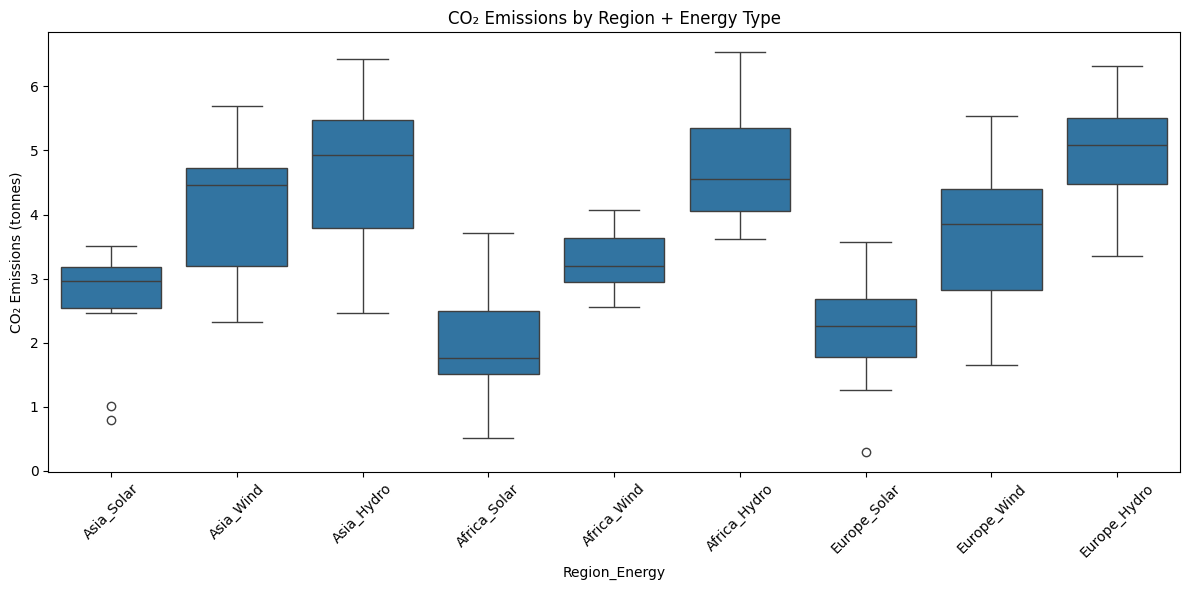

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Region_Energy", y="CO2_Emissions")
plt.title("CO₂ Emissions by Region + Energy Type")
plt.xticks(rotation=45)
plt.ylabel("CO₂ Emissions (tonnes)")
plt.tight_layout()
plt.show()

Step 5: Explore Further

In [31]:
# Try increasing emissions for 'Hydro'
df.loc[df["Energy_Type"] == "Hydro", "CO2_Emissions"] *= 1.2

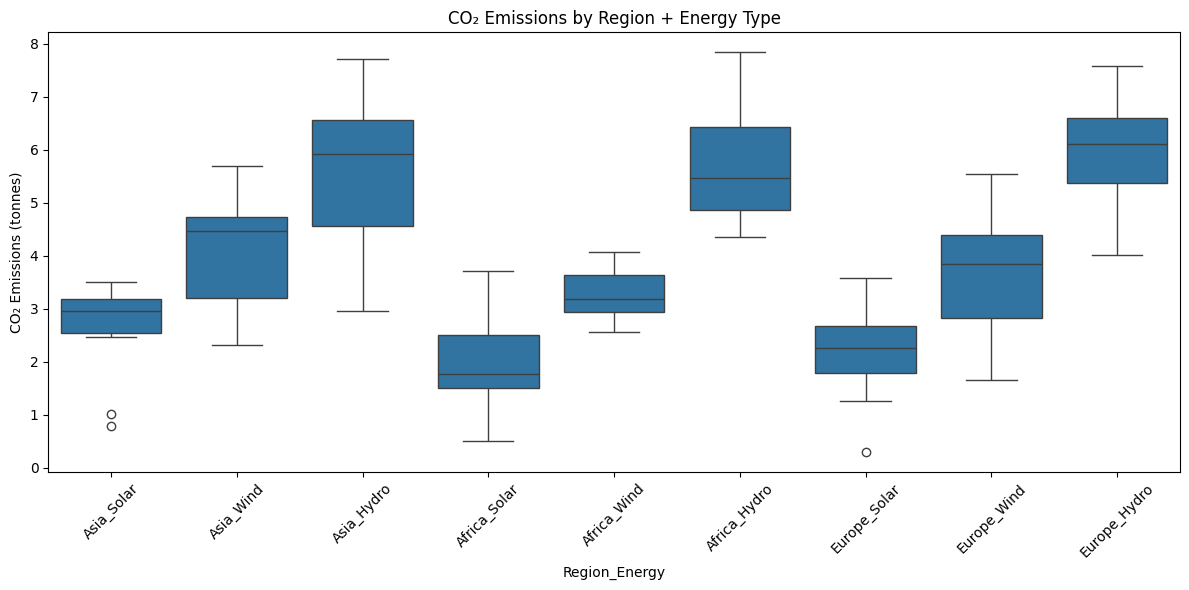

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Region_Energy", y="CO2_Emissions")
plt.title("CO₂ Emissions by Region + Energy Type")
plt.xticks(rotation=45)
plt.ylabel("CO₂ Emissions (tonnes)")
plt.tight_layout()
plt.show()

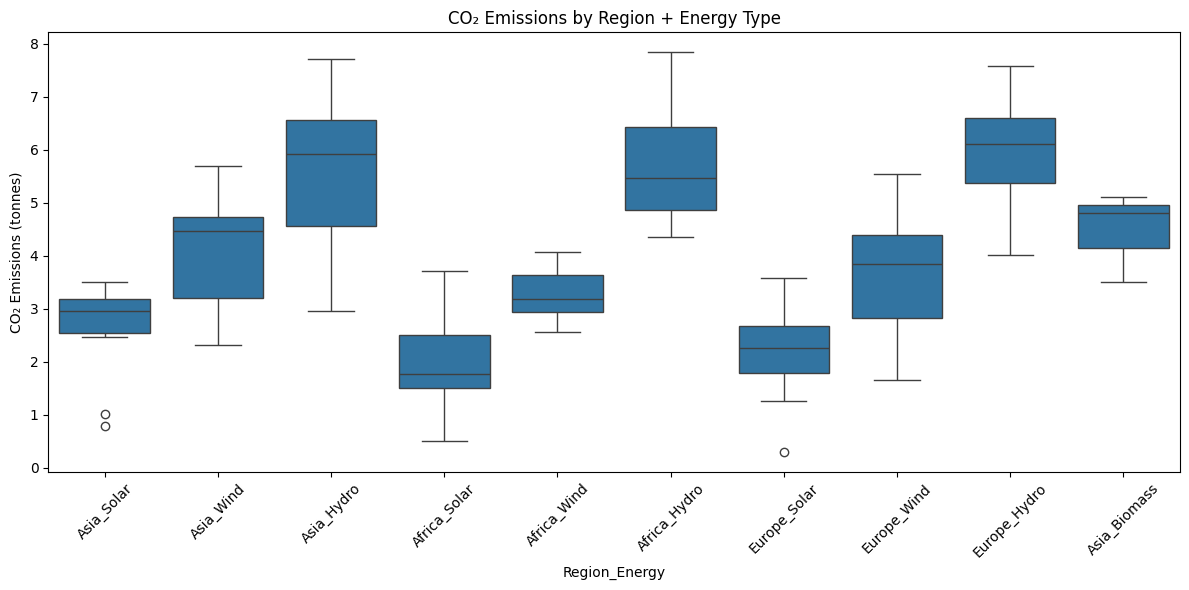

In [33]:
# Add a new row manually
# Add a few more rows of Biomass data to create a range
df.loc[len(df)] = ["Asia", "Biomass", 3.5, "Asia_Biomass", "Biomass_Asia"]
df.loc[len(df)] = ["Asia", "Biomass", 5.1, "Asia_Biomass", "Biomass_Asia"]
df.loc[len(df)] = ["Asia", "Biomass", 4.8, "Asia_Biomass", "Biomass_Asia"]

# Re-run the plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Region_Energy", y="CO2_Emissions")
plt.title("CO₂ Emissions by Region + Energy Type")
plt.xticks(rotation=45)
plt.ylabel("CO₂ Emissions (tonnes)")
plt.tight_layout()
plt.show()